# LightGBM LambdaMART — Optuna Hyperparameter Tuning

**Datasets:** `featured_full_train.csv` / `featured_full_test.csv`  
**Model:** LGBMRanker with `lambdarank` objective  
**CV:** StratifiedGroupKFold (3 folds, grouped by `id2` = customer)  
**Trials:** 20 Bayesian TPE trials (Optuna)  
**Metric:** MAP@7 (Mean Average Precision at 7)

## Pipeline Overview

```
featured_full_train.csv
        │
        ▼
  Drop leaky cols (_grp_pct, _grp_zscore)   ← within-group stats would leak future rows
        │
        ▼
  Sort by id2 (GROUP_COL)                   ← LightGBM requires contiguous groups
        │
        ▼
  Optuna TPE (20 trials × 3-fold SGKF)      ← tune lr, num_leaves, reg_lambda
        │
        ▼
  Retrain with best params (3-fold SGKF)    ← build final ensemble of 3 models
        │
        ├── OOF predictions  → MAP@7 on full training set
        └── Test predictions → MAP@7 on held-out test set
```

## Why LightGBM + LambdaMART?

| Reason | Detail |
|---|---|
| LambdaMART objective | Directly optimises NDCG/MAP via pairwise gradient-based ranking loss |
| `lambdarank_truncation_level=7` | Aligns truncation with the MAP@7 metric — only the top-7 positions matter |
| `label_gain=[0,1]` | Binary relevance: irrelevant=0, relevant=1 |
| StratifiedGroupKFold | Preserves positive-rate per fold AND keeps all rows of a customer together |
| Optuna TPE | Bayesian search is far more sample-efficient than grid/random search |

## Key Results

| Split | MAP@7 |
|---|---|
| OOF | _see Section 8 output_ |
| Test | _see Section 8 output_ |
| Best Optuna trial | _see Section 6 output_ |


## 1. Imports

Loads all required libraries:
- `lightgbm` — gradient-boosted ranking model
- `optuna` — Bayesian hyperparameter optimisation framework
- `StratifiedGroupKFold` — cross-validation that stratifies by target and groups by customer
- `shap` — (imported later in Section 10) for model explainability

LightGBM's C++ logger is silenced by registering a no-op `_SilentLogger` class and setting the Python logging level to CRITICAL. Optuna verbosity is set to WARNING to suppress per-trial noise.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import logging

# Suppress LightGBM C++ logger output
class _SilentLogger:
    def __getattr__(self, _):
        return lambda *a, **kw: None
lgb.register_logger(_SilentLogger())
logging.getLogger('lightgbm').setLevel(logging.CRITICAL)
import optuna
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f'LightGBM {lgb.__version__}  |  Optuna {optuna.__version__}')

LightGBM 4.6.0  |  Optuna 4.8.0


## 2. Load Data

Reads `featured_full_train.csv` and `featured_full_test.csv` — outputs of `feature_engineering.ipynb`.  
These files contain both raw `f*` columns and all engineered features.

**Leakage guard:** Columns ending in `_grp_pct` or `_grp_zscore` (within-group percentile/z-score statistics) are dropped immediately. These features use `groupby.transform()` over the entire split which would include future rows in the group — a form of look-ahead leakage in the ranking context.

The `_is_train` flag column (if present) is also dropped as it is a split indicator, not a signal.


In [2]:
TRAIN_PATH = '/kaggle/input/datasets/akashjaiswal1101/amex-dataset-2/featured_full_train (1).csv'
TEST_PATH  = '/kaggle/input/datasets/akashjaiswal1101/amex-dataset-2/featured_full_test (1).csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Drop any leaky columns that should never reach the model
leaky_cols = [c for c in train.columns
              if c.endswith('_grp_pct') or c.endswith('_grp_zscore') or c == '_is_train']
if leaky_cols:
    train.drop(columns=leaky_cols, inplace=True)
    test.drop(columns=[c for c in leaky_cols if c in test.columns], inplace=True)
    print(f'Dropped {len(leaky_cols)} leaky columns: {leaky_cols}')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')

Train shape : (616602, 350)
Test  shape : (153544, 350)


In [3]:
test


,id1,id2,id3,id4,id5,y,f1,f2,f5,f6,...,hour_of_day,is_business_hours,is_evening,is_morning,cx_weekend_x_high_value,cx_session_depth_x_offer_value,cx_prior_clicks_x_relevant_ctr,cx_recency_x_relevant_ctr,cx_offer_category_repeat,cx_relevance_score
0,1000078_622070_16-23_2023-11-02 03:40:44.605,1000078,622070,2023-11-02 03:40:44.605000,2023-11-02,0,NaN,NaN,NaN,NaN,...,3,0,0,0,0,0.000000,0.000000,0.000000,0.0,0.002981
1,1000125_78680_16-23_2023-11-01 21:06:27.987,1000125,78680,2023-11-01 21:06:27.987000,2023-11-01,0,NaN,26.0,22.0,NaN,...,21,0,1,0,0,0.266667,0.000000,0.000000,0.0,0.010697
2,1000125_481197_16-23_2023-11-01 21:06:28.369,1000125,481197,2023-11-01 21:06:28.369000,2023-11-01,0,NaN,26.0,22.0,NaN,...,21,0,1,0,0,0.000000,0.000000,0.000000,1.0,0.035697
3,1000125_69876_16-23_2023-11-01 21:06:30.618,1000125,69876,2023-11-01 21:06:30.618000,2023-11-01,0,NaN,26.0,22.0,NaN,...,21,0,1,0,0,0.900000,0.000000,0.000000,0.0,0.015109
4,1000125_241382_16-23_2023-11-01 21:06:31.355,1000125,241382,2023-11-01 21:06:31.355000,2023-11-01,0,NaN,26.0,22.0,NaN,...,21,0,1,0,0,1.846154,0.000000,0.000000,0.0,0.015109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153539,1910509_30717_16-23_2023-11-03 16:34:29.000658,1910509,30717,2023-11-03 16:34:29.000658,2023-11-03,1,NaN,100.0,6.0,43.0,...,16,1,0,0,0,0.400000,0.000000,0.000000,1.0,0.002981
153540,1910509_604959_16-23_2023-11-03 16:34:34.000754,1910509,604959,2023-11-03 16:34:34.000754,2023-11-03,1,NaN,100.0,6.0,43.0,...,16,1,0,0,0,0.000000,0.005569,0.005569,1.0,0.002981
153541,1910509_24840_16-23_2023-11-03 16:34:42.555,1910509,24840,2023-11-03 16:34:42.555000,2023-11-03,0,NaN,100.0,6.0,43.0,...,16,1,0,0,0,0.800000,0.011139,0.005569,1.0,0.002981
153542,1910509_648329_16-23_2023-11-03 16:34:43.000570,1910509,648329,2023-11-03 16:34:43.000570,2023-11-03,1,NaN,100.0,6.0,43.0,...,16,1,0,0,0,0.000000,0.011139,0.005569,1.0,0.002981


In [4]:
print('Target distribution (train):')
print(train['y'].value_counts(normalize=True).round(4))

Target distribution (train):
y
0    0.9512
1    0.0488
Name: proportion, dtype: float64


## 3. Feature & Column Definitions

Defines three column-group constants:

| Variable | Value | Purpose |
|---|---|---|
| `ID_COLS` | `['id1','id2','id3','id4','id5']` | Identifiers — excluded from features |
| `TARGET_COL` | `'y'` | Binary relevance label (0/1) |
| `GROUP_COL` | `'id2'` | Customer ID — defines query groups for LTR |

Then splits `FEATURE_COLS` into:
- **Raw features** — columns starting with `'f'` (original dataset columns)
- **Engineered features** — all other feature columns created by `feature_engineering.ipynb`

Categorical columns are set to `CAT_FEATURES = []` because `feature_engineering.ipynb` already integer-encoded all categoricals using `pd.CategoricalDtype` fitted on train rows only. Passing them to LightGBM's `categorical_feature` would cause redundant re-encoding.


In [5]:
ID_COLS    = ['id1', 'id2', 'id3', 'id4', 'id5']
TARGET_COL = 'y'
GROUP_COL  = 'id2'

In [6]:
# All categorical columns were already integer-encoded by feature_engineering.ipynb
# using pd.CategoricalDtype fitted on train rows only — no leakage.
# Passing them as LightGBM categorical_feature would trigger re-encoding inside LightGBM,
# which is redundant. Treat as plain numeric features.
CAT_FEATURES = []

print('CAT_FEATURES = [] — all columns are already integer-encoded by feature_engineering.ipynb')

CAT_FEATURES = [] — all columns are already integer-encoded by feature_engineering.ipynb


In [7]:
FEATURE_COLS = [c for c in train.columns if c not in ID_COLS + [TARGET_COL]]

eng_features = [c for c in FEATURE_COLS if not c.startswith('f')]
raw_features = [c for c in FEATURE_COLS if c.startswith('f')]

print(f'Total features     : {len(FEATURE_COLS)}')
print(f'  Raw f-columns    : {len(raw_features)}')
print(f'  Engineered       : {len(eng_features)}')

Total features     : 344
  Raw f-columns    : 238
  Engineered       : 106


## 4. Preprocessing

Two steps to prepare data for LightGBM's LambdaMART:
1. **Skip LabelEncoder** — all categoricals already integer-encoded upstream (Section 4A)
2. **Sort by GROUP_COL and build feature matrices** (Section 4B)


### 4A. Label-Encode Categoricals

**No-op section.** LabelEncoder is explicitly skipped because `feature_engineering.ipynb` already applied `pd.CategoricalDtype` encoding fitted on training rows only. Re-encoding here on combined train+test would introduce test-distribution leakage (the encoder would see test category values during `fit_transform`).


In [8]:
# LabelEncoder removed — all categorical columns are already integer-encoded by
# feature_engineering.ipynb (pd.CategoricalDtype fitted on train rows only).
# Re-encoding here on combined train+test would introduce test-distribution leakage.
print('No LabelEncoder needed — categoricals already integer-encoded by feature_engineering.ipynb.')

No LabelEncoder needed — categoricals already integer-encoded by feature_engineering.ipynb.


### 4B. Sort & Prepare Arrays

**Why sort?** LightGBM's `lgb.Dataset` with `group=` expects that all rows belonging to the same query (customer) are **contiguous** in the data. Sorting by `GROUP_COL` (`id2`) ensures this.  
Without sorting, `group_sizes_from_ids()` would produce incorrect group size arrays and the LambdaMART loss would pair rows from different customers.

After sorting, the data is split into:
- `X_train`, `y_train`, `g_train` — feature matrix, labels, group IDs for training
- `X_test`, `y_test`, `g_test` — same for held-out test set


In [9]:
# Sort by group — LightGBM requires contiguous groups
train = train.sort_values(GROUP_COL).reset_index(drop=True)
test  = test.sort_values(GROUP_COL).reset_index(drop=True)

print('Sorted by group column.')

Sorted by group column.


In [10]:
X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
g_train = train[GROUP_COL].values

X_test = test[FEATURE_COLS]
y_test = test[TARGET_COL]
g_test = test[GROUP_COL].values

print(f'X_train : {X_train.shape}  |  positive rate : {y_train.mean():.4f}')
print(f'X_test  : {X_test.shape}   |  positive rate : {y_test.mean():.4f}')

X_train : (616602, 344)  |  positive rate : 0.0488
X_test  : (153544, 344)   |  positive rate : 0.0455


## 5. MAP@K Evaluation Helpers

Three helper functions for computing the competition metric:

| Function | Input | Output | Notes |
|---|---|---|---|
| `apk(actual, predicted, k=7)` | Lists of relevant/predicted indices | AP@K scalar | Handles duplicate predictions; denominator = `min(len(actual), k)` |
| `map_at_k(y_true, y_score, k=7, groups)` | Arrays + group IDs | MAP@K scalar | Iterates over unique groups; skips groups with no positives |
| `group_sizes_from_ids(group_ids)` | Sorted group ID array | Array of sizes | Uses `np.unique(..., return_counts=True)`; feeds into `lgb.Dataset(group=...)` |

**Why `group_sizes_from_ids`?** LightGBM does not accept raw group IDs — it needs an array of group *sizes* (e.g., `[3, 5, 2, ...]` meaning first group has 3 rows, second has 5, etc.). This function converts sorted customer IDs to that format.


In [11]:
def apk(actual: list, predicted: list, k: int = 7) -> float:
    """Average Precision at K for a single query (binary relevance)."""
    if not actual:
        return 0.0
    predicted = predicted[:k]
    actual_set = set(actual)
    seen = set()
    score, hits = 0.0, 0.0
    for i, p in enumerate(predicted):
        if p in actual_set and p not in seen:
            seen.add(p)
            hits += 1
            score += hits / (i + 1.0)
    return score / min(len(actual), k)

In [12]:
def map_at_k(y_true, y_score, k: int = 7, groups=None) -> float:
    """MAP@K computed per customer (query group)."""
    y_true  = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if groups is None:
        order     = np.argsort(y_score)[::-1]
        actual    = list(np.where(y_true == 1)[0])
        predicted = list(order)
        return apk(actual, predicted, k)
    groups    = np.asarray(groups)
    ap_scores = []
    for grp in np.unique(groups):
        mask = groups == grp
        yt   = y_true[mask]
        ys   = y_score[mask]
        if yt.sum() == 0:
            continue
        order     = np.argsort(ys)[::-1]
        actual    = list(np.where(yt == 1)[0])
        predicted = list(order)
        ap_scores.append(apk(actual, predicted, k))
    return float(np.mean(ap_scores)) if ap_scores else 0.0

In [13]:
def group_sizes_from_ids(group_ids: np.ndarray) -> np.ndarray:
    """Convert sorted group id array to group size array for LightGBM."""
    _, counts = np.unique(group_ids, return_counts=True)
    return counts

print('Helpers defined.')

Helpers defined.


## 6. Optuna Bayesian Optimisation

Optuna's **TPE (Tree-structured Parzen Estimator)** sampler performs Bayesian optimisation — it builds a probabilistic model of the objective function and proposes parameter values that are likely to improve MAP@7, rather than sampling randomly.

**Search space:**

| Parameter | Range | Scale | Why |
|---|---|---|---|
| `learning_rate` | 0.005 – 0.30 | log | Small differences at low end matter most |
| `num_leaves` | 15 – 255 | linear | Controls model complexity / tree depth |
| `reg_lambda` | 0.01 – 50.0 | log | L2 regularisation; wide range needed |

**Fixed across all trials:**
- `objective='lambdarank'`, `metric='map'`, `eval_at=[7]`
- `lambdarank_truncation_level=7` — only top-7 positions matter for MAP@7
- `n_estimators=1000` with early stopping (50 rounds) on each fold's validation set
- `colsample_bytree=0.8`, `subsample=0.8` for stochastic boosting

**Fold strategy:** SPLITS are **pre-computed once** outside `objective()` so the same 3 folds are used for every trial — this removes fold-randomness as a confound and makes trial comparisons fair.

**Pruner:** `MedianPruner` kills trials that are clearly underperforming after 1 warmup step, saving compute.


In [14]:
N_FOLDS  = 3
N_TRIALS = 20

# Pre-compute fold splits (fixed across all trials)
sgkf   = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
SPLITS = list(sgkf.split(X_train, y_train, groups=g_train))

print(f'{N_FOLDS}-fold SGKF splits pre-computed.')

3-fold SGKF splits pre-computed.


In [15]:
def objective(trial):
    lr         = trial.suggest_float('learning_rate', 0.005, 0.3, log=True)
    num_leaves = trial.suggest_int('num_leaves', 15, 255)
    reg_lambda = trial.suggest_float('reg_lambda', 0.01, 50.0, log=True)

    params = dict(
        objective='lambdarank', metric='map', eval_at=[7],
        lambdarank_truncation_level=7, label_gain=[0, 1],
        n_estimators=1000,
        learning_rate=lr, num_leaves=num_leaves,
        min_child_samples=20, reg_lambda=reg_lambda,
        colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
        random_state=42, n_jobs=-1, verbose=-1,
        device='gpu', gpu_platform_id=0, gpu_device_id=0,
    )

    fold_maps = []
    for fold, (tr_idx, val_idx) in enumerate(SPLITS):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        g_tr, g_val = g_train[tr_idx],      g_train[val_idx]

        # No categorical_feature= — all columns already int-encoded by feature_engineering.ipynb
        train_ds = lgb.Dataset(
            X_tr, label=y_tr,
            group=group_sizes_from_ids(g_tr),
            free_raw_data=False,
        )
        val_ds = lgb.Dataset(
            X_val, label=y_val,
            group=group_sizes_from_ids(g_val),
            free_raw_data=False, reference=train_ds,
        )

        model = lgb.train(
            params, train_ds, valid_sets=[val_ds],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )

        val_scores = model.predict(X_val)
        fold_map = map_at_k(y_val.values, val_scores, k=7, groups=g_val)
        fold_maps.append(fold_map)

        trial.report(np.mean(fold_maps), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_maps)

print(f'Objective defined — {N_TRIALS} trials.')

Objective defined — 20 trials.


### Run Optimisation

Creates an Optuna study with:
- `direction='maximize'` — we want to maximise MAP@7
- `TPESampler(seed=42)` — reproducible Bayesian search
- `MedianPruner(n_startup_trials=5, n_warmup_steps=1)` — only start pruning after 5 full trials

Runs `N_TRIALS=20` trials. Each trial trains 3 LGBMRanker models (one per fold) and returns the mean MAP@7.  
After completion, `study.best_trial` and `study.best_params` hold the optimal configuration.


In [16]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    study_name='lgbm_ltr_map7_featured_full',
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


In [17]:
print(f'Best trial #{study.best_trial.number}')
print(f'  MAP@7 (CV mean) : {study.best_value:.4f}')
print(f'  Params:')
for k, v in study.best_params.items():
    print(f'    {k}: {v}')

Best trial #12
  MAP@7 (CV mean) : 0.6869
  Params:
    learning_rate: 0.09767883624362875
    num_leaves: 17
    reg_lambda: 43.18235348115647


### Optimisation Visualisation

Three diagnostic plots from `study.trials_dataframe()`:

1. **Optimisation History** — scatter of MAP@7 vs trial number, with red line = best-so-far curve. A rising best-so-far line confirms the TPE sampler is improving over time.

2. **Parameter Importance (correlation)** — Pearson correlation of each hyperparameter with MAP@7 across trials. The parameter with the largest absolute correlation has the most influence on the metric.

3. **Parallel Coordinates** — each trial is a polyline across parameter axes coloured by MAP@7. Allows visual identification of high-MAP@7 regions in the joint parameter space.


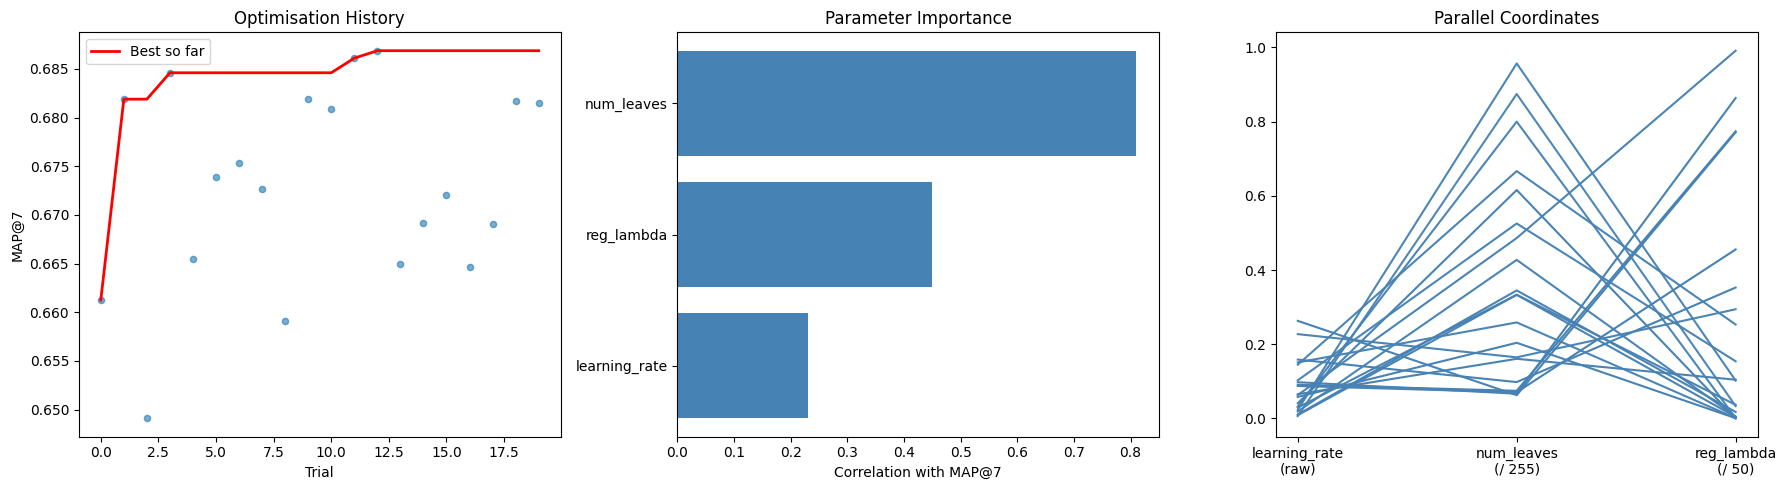

In [18]:
trials_df = study.trials_dataframe().dropna(subset=['value'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Optimisation History
axes[0].scatter(trials_df['number'], trials_df['value'], alpha=0.6, s=20)
best_so_far = trials_df['value'].cummax()
axes[0].plot(trials_df['number'], best_so_far, color='red', lw=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('MAP@7')
axes[0].set_title('Optimisation History')
axes[0].legend()

# 2. Parameter Importance
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
importances = trials_df[param_cols].corrwith(trials_df['value']).abs()
importances.index = [c.replace('params_', '') for c in importances.index]
importances = importances.sort_values()
axes[1].barh(importances.index, importances.values, color='steelblue')
axes[1].set_xlabel('Correlation with MAP@7')
axes[1].set_title('Parameter Importance')

# 3. Parallel Coordinates
for _, row in trials_df.iterrows():
    axes[2].plot(
        [row['params_learning_rate'], row['params_num_leaves'] / 255, row['params_reg_lambda'] / 50],
        alpha=0.15 + 0.85 * (row['value'] / trials_df['value'].max()),
        color='steelblue',
    )
axes[2].set_xticks([0, 1, 2])
axes[2].set_xticklabels(['learning_rate\n(raw)', 'num_leaves\n(/ 255)', 'reg_lambda\n(/ 50)'])
axes[2].set_title('Parallel Coordinates')

plt.tight_layout()
plt.savefig('/kaggle/working/optuna_lgbm_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Retrain with Best Params (3-Fold SGKF)

Takes `study.best_params` (the Optuna-optimised `learning_rate`, `num_leaves`, `reg_lambda`) and merges them with fixed parameters into `BEST_PARAMS`.

**Important fixed params:**

| Parameter | Value | Reason |
|---|---|---|
| `objective` | `'lambdarank'` | Pairwise ranking loss aligned with MAP |
| `lambdarank_truncation_level` | 7 | Only rank quality in top-7 positions matters |
| `label_gain` | `[0, 1]` | Binary labels: irrelevant=0, relevant=1 |
| `eval_at` | `[7]` | Evaluate MAP@7 during training |
| `device` | `'gpu'` | GPU acceleration on Kaggle (P100/T4) |
| `n_estimators` | 1000 | Max trees; early stopping prevents overfitting |

**Training loop per fold:**
1. Split into train/val by `SPLITS[fold]` (pre-computed StratifiedGroupKFold)
2. Build `lgb.Dataset` objects with `group=group_sizes_from_ids(...)` — LightGBM's required format
3. Train with `callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]`
4. Predict on val and test; accumulate `oof_preds` and `test_preds` (averaged across folds)
5. Compute per-fold MAP@7 using `map_at_k()`


In [19]:
BEST_PARAMS = dict(
    objective='lambdarank', metric='map', eval_at=[7],
    lambdarank_truncation_level=7, label_gain=[0, 1],
    n_estimators=1000, min_child_samples=20,
    colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
    random_state=42, n_jobs=-1, verbose=-1,
    device='gpu', gpu_platform_id=0, gpu_device_id=0,
    **study.best_params,
)

print('Best params merged:')
for k, v in BEST_PARAMS.items():
    print(f'  {k}: {v}')

Best params merged:
  objective: lambdarank
  metric: map
  eval_at: [7]
  lambdarank_truncation_level: 7
  label_gain: [0, 1]
  n_estimators: 1000
  min_child_samples: 20
  colsample_bytree: 0.8
  subsample: 0.8
  subsample_freq: 1
  random_state: 42
  n_jobs: -1
  verbose: -1
  device: gpu
  gpu_platform_id: 0
  gpu_device_id: 0
  learning_rate: 0.09767883624362875
  num_leaves: 17
  reg_lambda: 43.18235348115647


In [20]:
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
fold_maps  = []
models     = []

In [21]:
for fold, (tr_idx, val_idx) in enumerate(SPLITS, 1):
    print(f'\n{"="*60}')
    print(f'FOLD {fold}/{N_FOLDS}')
    print(f'{"="*60}')

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    g_tr, g_val = g_train[tr_idx],      g_train[val_idx]

    print(f'  Train: {len(X_tr):,} rows, {len(np.unique(g_tr)):,} customers')
    print(f'  Val  : {len(X_val):,} rows, {len(np.unique(g_val)):,} customers')

    # No categorical_feature= — all columns already int-encoded by feature_engineering.ipynb
    train_ds = lgb.Dataset(
        X_tr, label=y_tr,
        group=group_sizes_from_ids(g_tr),
        free_raw_data=False,
    )
    val_ds = lgb.Dataset(
        X_val, label=y_val,
        group=group_sizes_from_ids(g_val),
        free_raw_data=False, reference=train_ds,
    )

    model = lgb.train(
        BEST_PARAMS, train_ds, valid_sets=[val_ds],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    val_scores = model.predict(X_val)
    oof_preds[val_idx] = val_scores
    test_preds += model.predict(X_test) / N_FOLDS

    fold_map = map_at_k(y_val.values, val_scores, k=7, groups=g_val)
    fold_maps.append(fold_map)
    models.append(model)

    print(f'  Best iteration : {model.best_iteration}')
    print(f'  Fold {fold} MAP@7  : {fold_map:.4f}')


FOLD 1/3
  Train: 409,885 rows, 24,817 customers
  Val  : 206,717 rows, 12,423 customers
  Best iteration : 245
  Fold 1 MAP@7  : 0.6991

FOLD 2/3
  Train: 405,217 rows, 24,847 customers
  Val  : 211,385 rows, 12,393 customers
  Best iteration : 244
  Fold 2 MAP@7  : 0.6764

FOLD 3/3
  Train: 418,102 rows, 24,816 customers
  Val  : 198,500 rows, 12,424 customers
  Best iteration : 243
  Fold 3 MAP@7  : 0.6851


In [22]:
print(f'{"="*60}')
print(f'CV MAP@7 : {np.mean(fold_maps):.4f} +/- {np.std(fold_maps):.4f}')
print(f'{"="*60}')

CV MAP@7 : 0.6869 +/- 0.0094


## 8. OOF Evaluation

**Out-of-Fold (OOF) evaluation** gives an unbiased estimate of generalisation performance:
- Each training row was predicted exactly once by the fold it was held out from
- `oof_map` is therefore a proper cross-validated score with no data leakage

**Test MAP@7** uses predictions averaged across all 3 fold models — ensemble averaging reduces variance.

The summary DataFrame shows:
- `Fold 1 / Fold 2 / Fold 3` — per-fold validation MAP@7
- `OOF` — combined OOF MAP@7 across all folds
- `Test` — MAP@7 on the held-out test set
- `CV Mean` — arithmetic mean of the 3 fold scores

Also prints `study.best_params` for reference alongside the results.


In [23]:
oof_map  = map_at_k(y_train.values, oof_preds, k=7, groups=g_train)
test_map = map_at_k(y_test.values,  test_preds, k=7, groups=g_test)

summary = pd.DataFrame({
    'Split' : [f'Fold {i}' for i in range(1, N_FOLDS + 1)] + ['OOF', 'Test'],
    'MAP@7' : fold_maps + [oof_map, test_map],
}).set_index('Split')
summary.loc['CV Mean'] = [np.mean(fold_maps)]

print(summary.round(4).to_string())
print(f'\nBest Optuna params: {study.best_params}')

          MAP@7
Split          
Fold 1   0.6991
Fold 2   0.6764
Fold 3   0.6851
OOF      0.6868
Test     0.6729
CV Mean  0.6869

Best Optuna params: {'learning_rate': 0.09767883624362875, 'num_leaves': 17, 'reg_lambda': 43.18235348115647}


## 9. Feature Importance (Gain)

Computes **gain-based feature importance** for each of the 3 fold models using `.feature_importance(importance_type='gain')`, then averages across folds to reduce fold-specific variance.

**Gain importance** measures the total reduction in the loss function attributed to splits on each feature across all trees — a higher gain means the feature produces better-quality splits.

Results are sorted descending and the top-30 features are:
1. Printed as a table
2. Plotted as a horizontal bar chart saved to `feature_importance_lgbm_optuna.png`

Averaging across folds is important: a feature that appears important in only one fold may be capturing fold-specific noise rather than a true signal.


In [24]:
feat_imp = pd.DataFrame({'feature': FEATURE_COLS})
for i, m in enumerate(models):
    feat_imp[f'gain_{i}'] = m.feature_importance(importance_type='gain')
feat_imp['mean_gain'] = feat_imp[[f'gain_{i}' for i in range(N_FOLDS)]].mean(axis=1)
feat_imp = feat_imp.sort_values('mean_gain', ascending=False).reset_index(drop=True)

print('Top 30 features (gain):')
print(feat_imp[['feature', 'mean_gain']].head(30).to_string(index=False))

Top 30 features (gain):
                    feature    mean_gain
       time_since_last_seen 26763.124350
      time_since_last_click  9589.559850
    pace_x_offer_popularity  5570.862998
        session_event_count  3531.883163
                       f312  3264.303826
                       f311  2728.829427
    cx_merchant_click_share  2309.258805
                       f210  2116.830179
                       f336  1714.925571
                       f314  1639.576789
                       f337  1319.656080
    no_of_clicks_previously  1304.396834
                       f358  1173.198629
                 pace_x_ctr  1027.051317
                       f206  1004.503446
    previous_offer_category   975.872700
                       f207   738.984452
                       f219   677.433858
cx_industry_vs_merchant_ctr   590.486398
                       f340   553.663069
                       f339   535.144210
                       f216   464.116096
                       f224   439

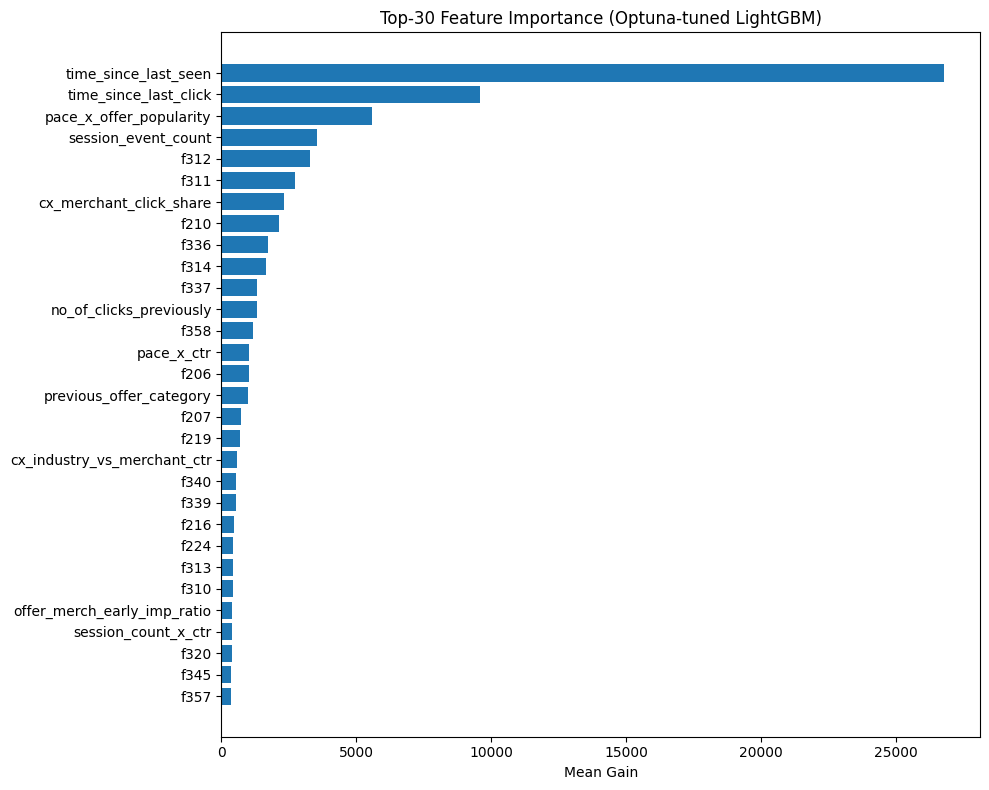

In [25]:
top_n = 30
fig, ax = plt.subplots(figsize=(10, 8))
top = feat_imp.head(top_n)
ax.barh(range(top_n), top['mean_gain'].values)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Mean Gain')
ax.set_title(f'Top-{top_n} Feature Importance (Optuna-tuned LightGBM)')
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance_lgbm_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. SHAP Analysis

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions that sum to `prediction - base_value`. This provides **model-level** and **instance-level** explainability.

**Why the best-fold model?** SHAP is computed on one model to avoid averaging SHAP values across models with different tree structures (which would be mathematically inconsistent). The best fold's validation set is the most representative evaluation sample.

**Why subsample to 5000?** TreeExplainer is O(n × features × trees). At full validation-set size this can take minutes; 5000 rows gives stable SHAP estimates in seconds.


In [26]:
import shap

best_fold_idx = int(np.argmax(fold_maps))
best_model = models[best_fold_idx]
print(f'Using Fold {best_fold_idx + 1} model (MAP@7 = {fold_maps[best_fold_idx]:.4f})')

Using Fold 1 model (MAP@7 = 0.6991)


In [27]:
# Sample validation data for SHAP
_, val_idx = SPLITS[best_fold_idx]
X_val_shap = X_train.iloc[val_idx]

SHAP_SAMPLE = 5000
if len(X_val_shap) > SHAP_SAMPLE:
    X_val_shap = X_val_shap.sample(SHAP_SAMPLE, random_state=42)
    print(f'Subsampled to {SHAP_SAMPLE} rows')

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_shap)
print(f'SHAP values shape: {shap_values.shape}')

Subsampled to 5000 rows
SHAP values shape: (5000, 344)


### 10A. SHAP Summary Plot

**Beeswarm plot** — each dot is one sample. Features are sorted by mean |SHAP| (most impactful at top).

- **X-axis:** SHAP value — positive means the feature pushed the prediction higher (more likely to be relevant/recommended)
- **Colour:** Feature value (blue=low, red=high)

**How to read it:** A red cluster on the right side of a feature means high feature values increase the predicted relevance score. A blue cluster on the right means *low* feature values are associated with higher relevance.

Saved to `shap_summary_lgbm_optuna.png`.


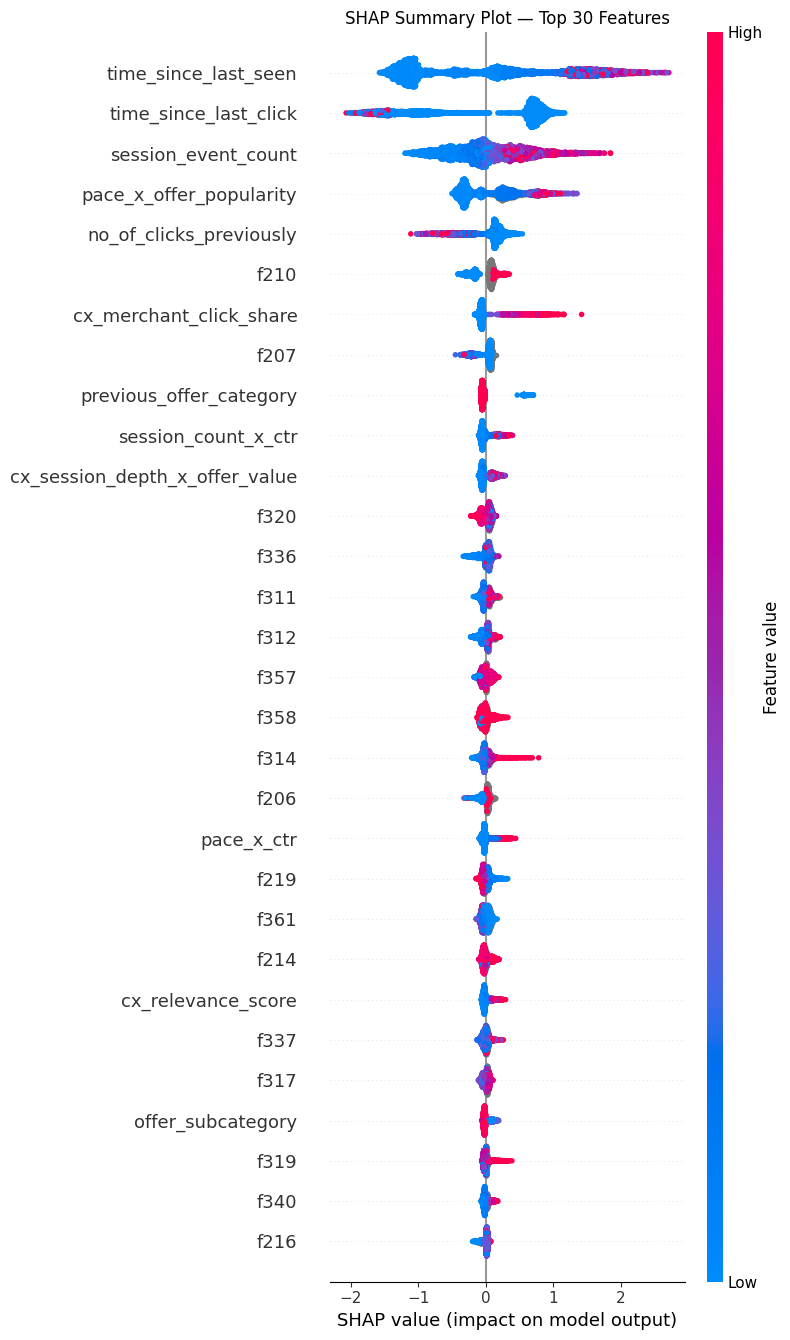

In [28]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_val_shap, max_display=30, show=False)
plt.title('SHAP Summary Plot — Top 30 Features')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_summary_lgbm_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

### 10B. SHAP Bar Plot (Mean |SHAP|)

Aggregates the beeswarm into a single bar per feature showing **mean absolute SHAP value** across all samples.

- Provides a clean ranking of global feature importance by magnitude of impact (direction-agnostic)
- Complements gain importance (Section 9): a feature may have high gain but small SHAP if its splits reduce loss without large score shifts

Saved to `shap_bar_lgbm_optuna.png`.


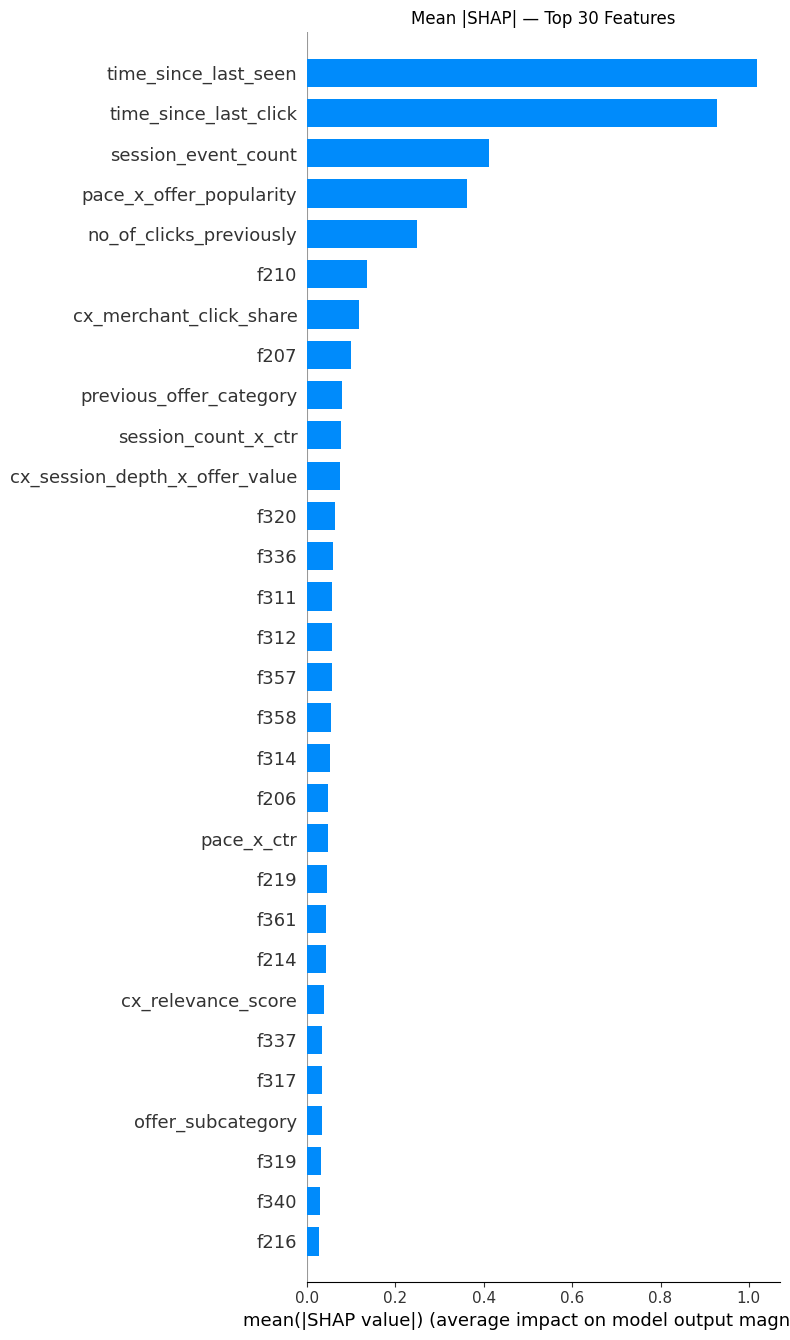

In [29]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_val_shap, plot_type='bar', max_display=30, show=False)
plt.title('Mean |SHAP| — Top 30 Features')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_bar_lgbm_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

### 10C. SHAP Dependence Plots (Top 4 Features)

For the 4 most impactful features (by mean |SHAP|), plots `feature value` (x-axis) vs `SHAP value` (y-axis) with a secondary colour-coding by an automatically selected interaction feature.

**What to look for:**
- A monotonic positive trend → higher feature value always increases the predicted relevance score
- Non-linear shapes → the model has learned a threshold effect (e.g., feature > X strongly boosts rank)
- Colour separation → interaction effect: the same feature value has different SHAP depending on another feature

Arranged in a 2×2 grid; saved to `shap_dependence_lgbm_optuna.png`.


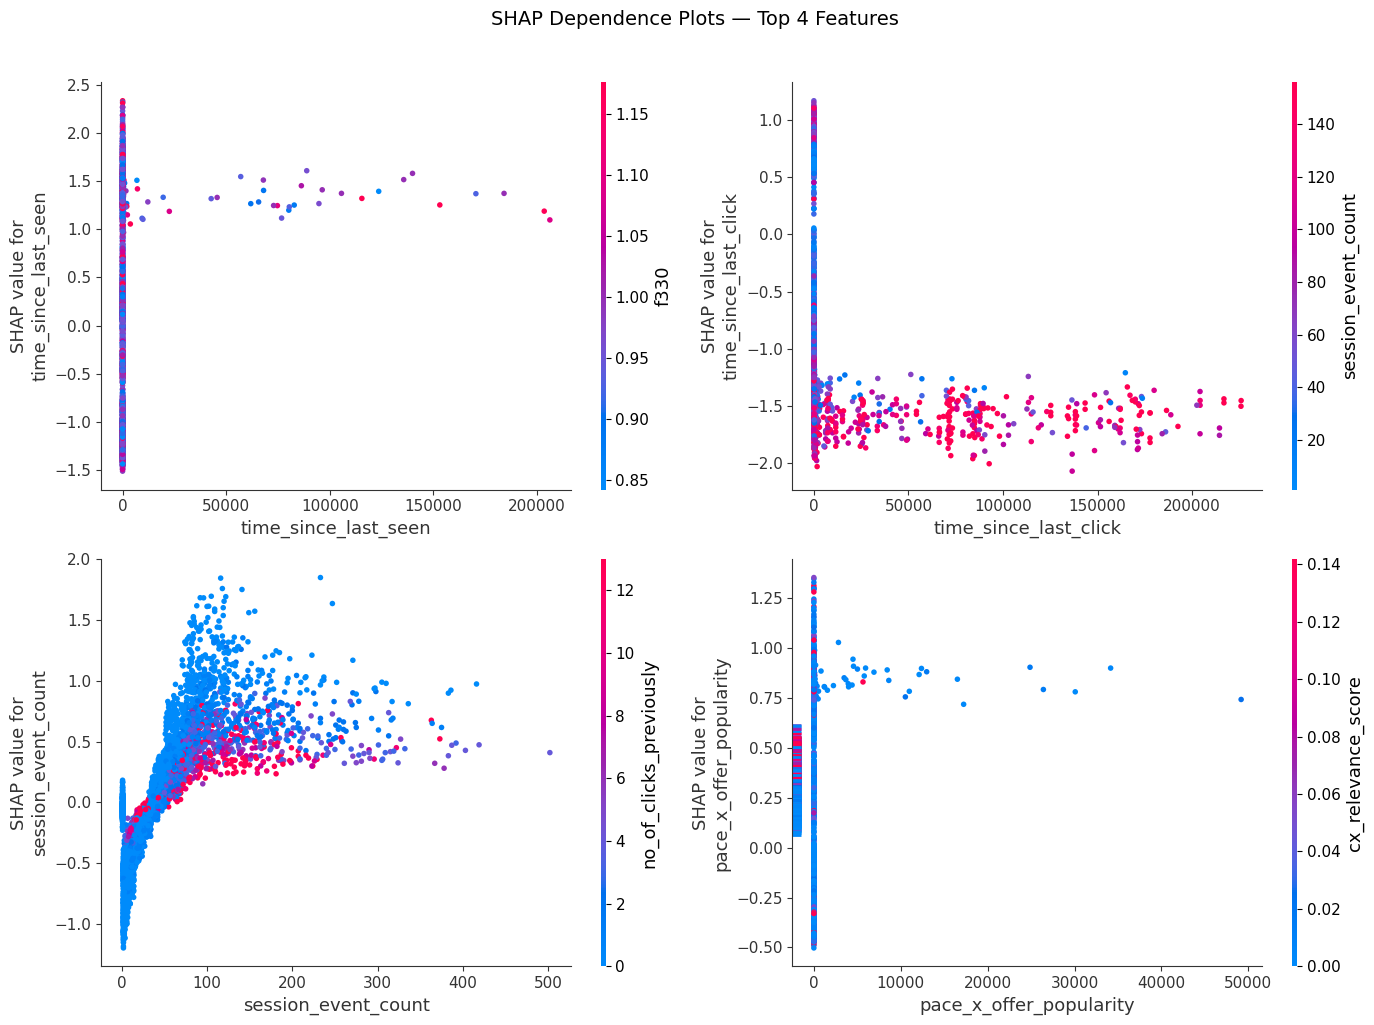

In [30]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top4_features = X_val_shap.columns[np.argsort(mean_abs_shap)[::-1][:4]].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top4_features):
    shap.dependence_plot(feat, shap_values, X_val_shap, ax=ax, show=False)
plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/shap_dependence_lgbm_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

### 10D. SHAP Waterfall (Single Prediction)

Shows how a single prediction is built up from the base value (average model output) by each feature's contribution:
- **Red bars** — features that *increase* the prediction above the base
- **Blue bars** — features that *decrease* the prediction
- **Final value** — sum of base + all SHAP values = model's raw output for this row

Useful for explaining individual offer recommendations to a business stakeholder: "This offer was ranked high because [feature X] was high (+0.12) and [feature Y] was also above average (+0.08)."


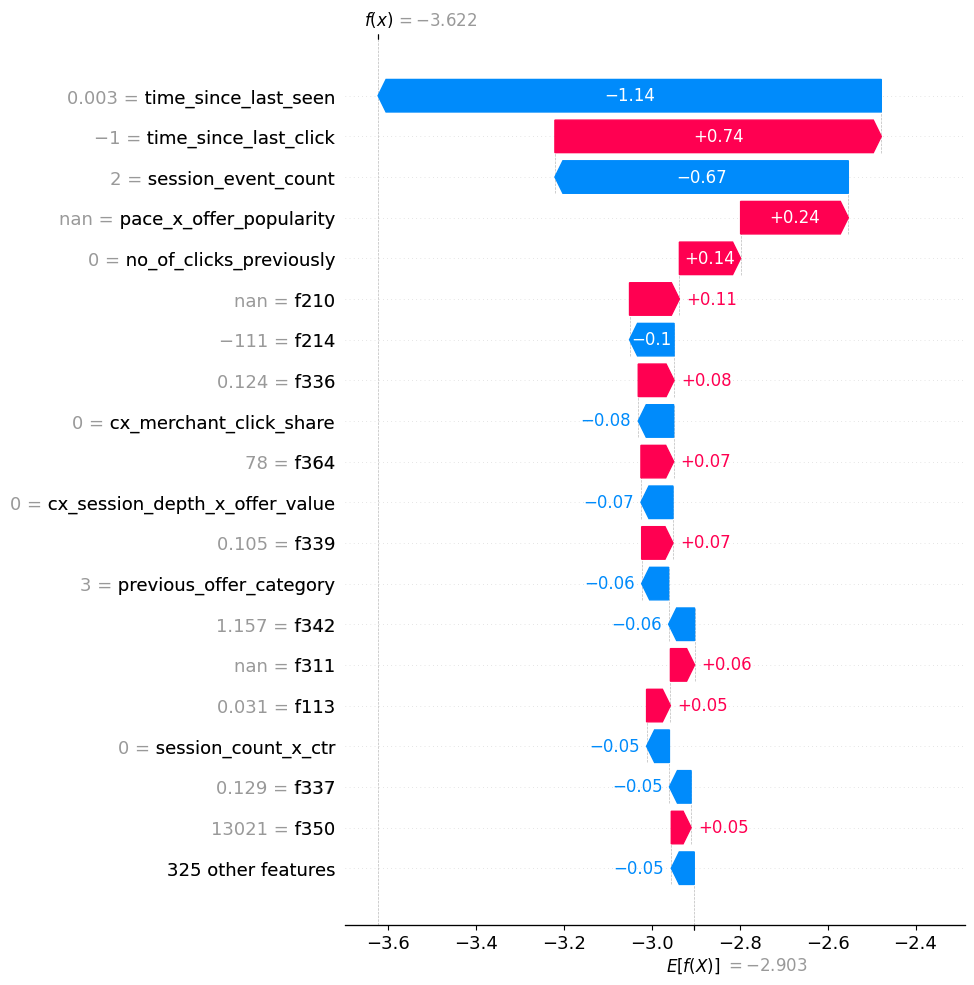

In [31]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_val_shap.values,
    feature_names=X_val_shap.columns.tolist(),
)

shap.plots.waterfall(shap_explanation[0], max_display=20, show=True)

## Summary

| Step | Detail |
|---|---|
| Datasets | `featured_full_train.csv` / `featured_full_test.csv` |
| Sorting | By `id2` (GROUP_COL) — required for contiguous LightGBM groups |
| Leakage guard | Dropped `_grp_pct` / `_grp_zscore` columns before any modelling |
| Categoricals | No re-encoding needed — `feature_engineering.ipynb` already integer-encoded |
| CV strategy | `StratifiedGroupKFold(n_splits=3)` — preserves positive rate, no customer leak |
| Hyperparameter search | Optuna TPE sampler, 20 trials, maximise mean MAP@7 across 3 folds |
| Tuned parameters | `learning_rate`, `num_leaves`, `reg_lambda` |
| Fixed parameters | `lambdarank`, `lambdarank_truncation_level=7`, `label_gain=[0,1]`, GPU |
| OOF MAP@7 | _see Section 8 output_ |
| Test MAP@7 | _see Section 8 output_ |
| Explainability | SHAP TreeExplainer on best-fold model (5000-row subsample): beeswarm, bar, dependence, waterfall |
| Saved artefacts | `feature_importance_lgbm_optuna.png`, `shap_summary_lgbm_optuna.png`, `shap_bar_lgbm_optuna.png`, `shap_dependence_lgbm_optuna.png` |
